In [2]:
import pandas as pd

df = pd.read_csv("cyberfeddefender_dataset.csv")

print(df.head())
print(df.info())

ModuleNotFoundError: No module named 'pandas'

In [2]:
df = df.dropna()
df = pd.get_dummies(df)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(df)

In [3]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=100,
    contamination=0.05,  
    random_state=42
)

model.fit(X)

,n_estimators,100
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [4]:
predictions = model.predict(X)

df['anomaly'] = predictions

print(df['anomaly'].value_counts())

anomaly
 1    1358
-1      72
Name: count, dtype: int64


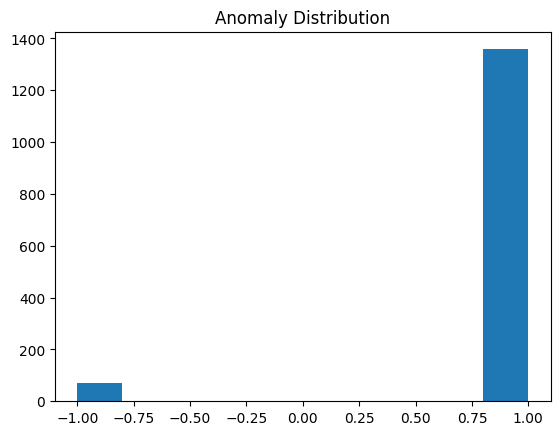

In [5]:
import matplotlib.pyplot as plt

plt.hist(predictions)
plt.title("Anomaly Distribution")
plt.show()